In [1]:
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2
%aimport

Modules to reload:
all-except-skipped

Modules to skip:



In [3]:
import os
import sys
import yaml
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

proj_root = f'{os.environ["HOME"]}/github/timer'
sys.path.append(proj_root)

In [4]:
fp = os.path.join(proj_root, 'examples/toi2123/sys.yaml')
sys_params = yaml.load(open(fp), Loader=yaml.FullLoader)
sys_params

{'planets': {'b': {'ror': [0.0412, 0.0008],
   'dur': [0.1533, 0.0017],
   'b': [0.07, 0.06],
   't0': [2458990.816843, 0.00144],
   'period': [10.308813, 2.4e-05]}},
 'star': {'mass': [0.904, 0.028],
  'radius': [0.838, 0.012],
  'teff': [5464, 69],
  'logg': [4.548, 0.0213],
  'feh': [-0.02, 0.07]}}

In [5]:
fp = os.path.join(proj_root, 'examples/toi2123/fit.yaml')
fit_params = yaml.load(open(fp), Loader=yaml.FullLoader)
fit_params

{'data': {'s25-1': {'file': 'TESS20200521.txt', 'band': 'T', 'spline': True}},
 'planets': 'b',
 'tc_pred': 2458990.82,
 'tc_pred_unc': 0.06,
 'unif': ['ror', 'dur', 'b'],
 'unif_nsig': 20}

In [6]:
from timer.fit import TransitFit

wd = os.path.join(proj_root, 'examples/toi2123')
fit = TransitFit(sys_params, fit_params, wd=wd)
# fit.build_model()
# fit.sample()

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


setting default: fixed = ['period', 'u_star']
setting default: fit_basis = duration
setting default: chromatic = False
setting default: include_mean = True
setting default: use_gp = False
setting default: tune = 2000
setting default: draws = 2000
setting default: chains = 2
setting default: cores = 2
setting default: clobber = False
setting default: inferencedata = False
setting default for s25-1: add_bias = False
setting default for s25-1: quadratic = False
setting default for s25-1: trend = None
setting default for s25-1: trim_beg = None
setting default for s25-1: trim_end = None
setting default for s25-1: nsig_clip = 7
setting default for s25-1: binsize = 0.003472222222222222
setting default for s25-1: chunk_offset = False
setting default for s25-1: chunk_thresh = 0
loading data: TESS20200521.txt
data span: 2020-05-21 01:40:03.199 - 2020-05-21 13:34:03.147
ref. time: 2458990
loading mask(s) from mask.pkl
loading model from model.pkl
loading MAP solution from map.pkl
loading trace fr

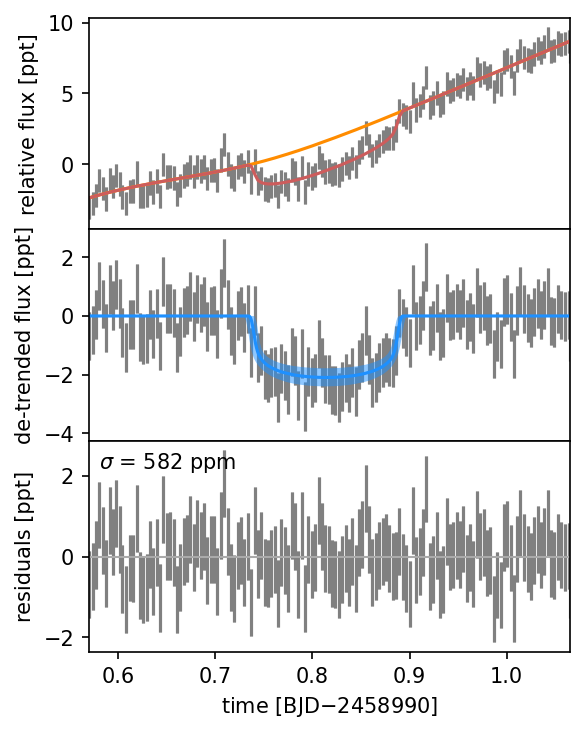

In [13]:
name = list(fit_params['data'].keys())[0]
fit.plot(name)

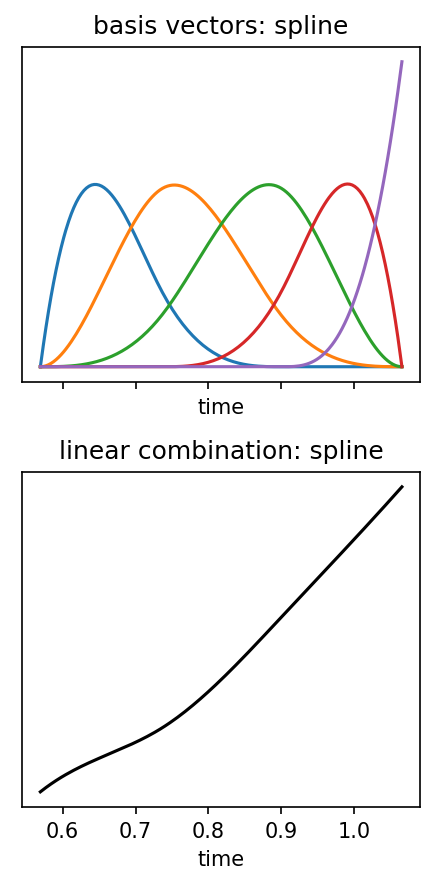

In [46]:
import numpy as np

spline = fit.fit_params['data'][name]['spline']
x = fit.data[name]['x']
X = fit.data[name]['X']
mask = fit.masks[name]
w = fit.map_soln[f'{name}_weights']
nspline = 5
covariates = not nspline == X.shape[1]
ncovariates = X.shape[1] - nspline

x_ = x[mask]
X_cov = X[mask,:ncovariates]
X_spl = X[mask,ncovariates:(ncovariates+nspline)]
w_cov = w[:ncovariates]
w_spl = w[ncovariates:(ncovariates+nspline)]

if covariates and spline:
    fig, axs = plt.subplots(2, 2, figsize=(6,6), sharex=True)
elif covariates or spline:
    fig, axs = plt.subplots(2, 1, figsize=(3,6), sharex=True)

def plot(axs, x, X, w, name):
    axs[0].plot(x, X)
    axs[1].plot(x, np.dot(X,w), color='k')
    plt.setp(axs[0], title=f'basis vectors: {name}')
    plt.setp(axs[1], title=f'linear combination: {name}')
    
if covariates and not spline:
    plot(axs, x_, X_cov, w_cov, 'covariates')

elif spline and not covariates:
    plot(axs, x_, X_spl, w_spl, 'spline')

elif spline and covariates:
    plot(axs[:,0], x_, X_cov, w_cov, 'covariates')
    plot(axs[:,1], x_, X_spl, w_spl, 'spline')

plt.setp(axs, xlabel='time', yticks=[])
# plt.setp(axs, xlabel='time')
fig.tight_layout()

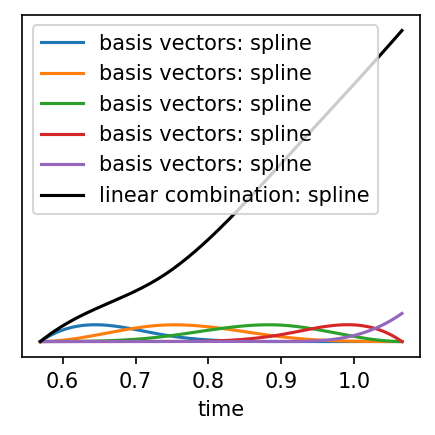

In [47]:
if covariates and spline:
    fig, axs = plt.subplots(1, 2, figsize=(6,3), sharex=True)
elif covariates or spline:
    fig, ax = plt.subplots(1, 1, figsize=(3,3), sharex=True)

def plot(ax, x, X, w, name):
    ax.plot(x, X, label=f'basis vectors: {name}')
    ax.plot(x, np.dot(X,w), color='k', label=f'linear combination: {name}')
    ax.legend()
    
if covariates and not spline:
    plot(ax, x_, X_cov, w_cov, 'covariates')

elif spline and not covariates:
    plot(ax, x_, X_spl, w_spl, 'spline')

elif spline and covariates:
    plot(axs[0], x_, X_cov, w_cov, 'covariates')
    plot(axs[1], x_, X_spl, w_spl, 'spline')

plt.setp(ax, xlabel='time', yticks=[])
fig.tight_layout()

In [ ]:
plt.plot(x_, np.dot(X_cov,w_cov), label='covariates')
plt.plot(x_, np.dot(X_spl,w_spl), label='spline')
plt.plot(x_, np.dot(X_cov,w_cov) + np.dot(X_spl,w_spl), label='sum')
plt.legend()